# Kymograph reference images

This notebook shows how to load and view microscope reference images associated with line-scan kymographs.

When performing line scans to form a kymograph image, commercial microscopes often, but not always, save a reference or overview image. The reference image helps relate the kymograph back to the spatial region where the line scan was acquired. CloudScope exposes these reference images through the public `AcqImage` API.

Current reference-image and scan-path support is under active development. The examples below use the current public `ReferenceImage` API, especially `get_plane()` and `get_scan_path_plot()`.

CloudScope's CZI and OIR support builds on file-format work by Christoph Gohlke:

- [`czifile`](https://github.com/cgohlke/czifile)
- [`oirfile`](https://github.com/cgohlke/oirfile)

## Imports

The CloudScope runtime does not depend on Matplotlib. Matplotlib is used here only for notebook/documentation examples.

In [10]:
from pathlib import Path
from pprint import pprint

import matplotlib.pyplot as plt

from acqstore.acq_image import AcqImage

## Example 1: OIR reference image

This OIR example is the primary walkthrough. It demonstrates the common workflow:

1. Load an `AcqImage`.
2. Inspect the main line-scan kymograph header.
3. Access the reference image.
4. Select a display plane.
5. Plot the reference image.
6. Overlay the scan path when it is available.

The scope that generated this OIR file could acquire one line scan at a time. In that case, the scan path is a simple line segment. CloudScope exposes it through the same `reference.get_scan_path_plot()` API used for other formats.

In [11]:
oir_path = Path("/Users/cudmore/Sites/cloudscope-data/czi-examples/ref-image/20251030_A106_0002.oir")
print(oir_path)
print("exists:", oir_path.exists())

acq = AcqImage(str(oir_path))
print(acq.name)
pprint(acq.images.header.as_dict())

/Users/cudmore/Sites/cloudscope-data/czi-examples/ref-image/20251030_A106_0002.oir
exists: True
20251030_A106_0002.oir
{'date': '20251030',
 'dims': ('Y', 'X'),
 'dtype': dtype('uint16'),
 'file_size': '5.9 MB',
 'num_channels': 1,
 'num_scenes': 1,
 'path': '/Users/cudmore/Sites/cloudscope-data/czi-examples/ref-image/20251030_A106_0002.oir',
 'physical_units': (0.0005350211513449023, 0.011413784562024583),
 'physical_units_labels': ('Y', 'X'),
 'shape': (30000, 24),
 'sizes': {'X': 24, 'Y': 30000},
 'time': '14:54:36'}


## Inspect the OIR reference image

`acq.images.reference_image` returns a `ReferenceImage` object when the file contains a reference image. The object is independent of the GUI and can be used directly from scripts or notebooks.

In [12]:
reference = acq.images.reference_image
if reference is None:
    raise RuntimeError(f"No reference image found for {acq.path}")

print("reference shape:", reference.array.shape)
print("reference dims:", reference.dims)
print("reference channels:", reference.num_channels)
print("has scan path:", reference.has_scan_path())
print("line ROI:", reference.get_line_roi())
print("coord units:", reference.coord_units)
print("coord scales:", reference.coord_scales)

reference shape: (512, 512)
reference dims: ('Y', 'X')
reference channels: 1
has scan path: True
line ROI: (250.0, 236.0, 244.0, 214.0)
coord units: (('X', 'µm'), ('Y', 'µm'))
coord scales: (('X', 0.0005350211513449023), ('Y', 0.0005350211513449023))


## Plot the OIR reference image and scan path

For this OIR file, `get_scan_path_plot()` returns two arrays, `x_pixels` and `y_pixels`, that can be passed directly to Matplotlib. For a simple line scan, the path has two points: the line start and line end.

OIR scan-path support depends on metadata saved by the microscope/scanner. The current OIR example is a single line segment. Support for reference images and scan paths is under active development, and exact behavior may change as more files and scanner modes are tested.

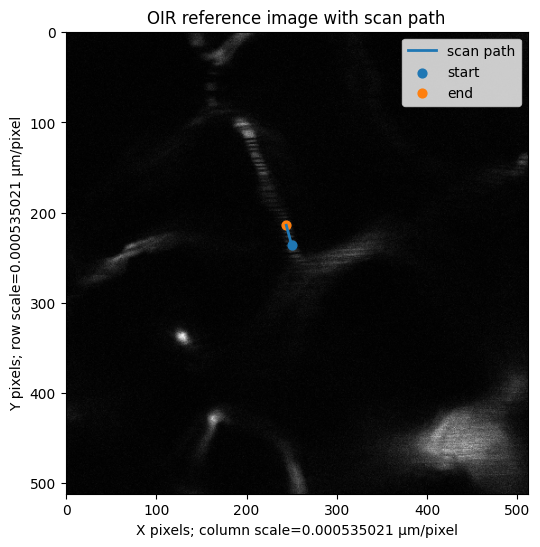

In [13]:
# OIR reference image has one channel, so channel=None or channel=0 is fine.
plane = reference.get_plane(channel=0)
scan_path = reference.get_scan_path_plot()

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(plane.array, cmap="gray", origin="upper")
ax.set_title("OIR reference image with scan path")
ax.set_xlabel(f"X pixels; column scale={plane.dy:g} {plane.y_unit}/pixel")
ax.set_ylabel(f"Y pixels; row scale={plane.dx:g} {plane.x_unit}/pixel")

if scan_path is not None:
    x_pixels, y_pixels = scan_path
    ax.plot(x_pixels, y_pixels, linewidth=2, label="scan path")
    ax.scatter([x_pixels[0]], [y_pixels[0]], s=40, label="start")
    ax.scatter([x_pixels[-1]], [y_pixels[-1]], s=40, label="end")
    ax.legend(loc="best")
else:
    ax.text(
        0.02,
        0.98,
        "No scan path metadata",
        transform=ax.transAxes,
        va="top",
        ha="left",
        bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.75},
    )

plt.show()

## Example 2: CZI reference image

CZI files can be extended to acquire multiple disjoint line scans. The scan path shown here is an example of that kind of path overlay.

CloudScope can load and display the reference image and currently exposes a plot-ready scan path through `reference.get_scan_path_plot()`. CZI scan-path support is still being refined as more CZI acquisition modes are tested. The public API may change as this work stabilizes.

In [14]:
czi_path = Path("/Users/cudmore/Sites/cloudscope-data/czi-examples/ref-image/Image 11.czi")
print(czi_path)
print("exists:", czi_path.exists())

czi_acq = AcqImage(str(czi_path))
print(czi_acq.name)
pprint(czi_acq.images.header.as_dict())

CZI header dims ('C', 'T', 'X') at '/Users/cudmore/Sites/cloudscope-data/czi-examples/ref-image/Image 11.czi': remapping 'T' axis to 'Y' for CloudScope (Y, X) convention


/Users/cudmore/Sites/cloudscope-data/czi-examples/ref-image/Image 11.czi
exists: True
Image 11.czi
{'date': '',
 'dims': ('C', 'Y', 'X'),
 'dtype': dtype('uint8'),
 'file_size': '8.5 MB',
 'num_channels': 2,
 'num_scenes': 1,
 'path': '/Users/cudmore/Sites/cloudscope-data/czi-examples/ref-image/Image '
         '11.czi',
 'physical_units': (1.0, 0.012910592000480392, 1.3837763734996583e-07),
 'physical_units_labels': ('C', 'Y', 'X'),
 'shape': (2, 3756, 1024),
 'sizes': {'C': 2, 'X': 1024, 'Y': 3756},
 'time': ''}


## Inspect the CZI reference image

In [15]:
czi_reference = czi_acq.images.reference_image
if czi_reference is None:
    raise RuntimeError(f"No reference image found for {czi_acq.path}")

print("reference shape:", czi_reference.array.shape)
print("reference dims:", czi_reference.dims)
print("reference channels:", czi_reference.num_channels)
print("has scan path:", czi_reference.has_scan_path())
print("line ROI:", czi_reference.get_line_roi())
print("coord units:", czi_reference.coord_units)
print("coord scales:", czi_reference.coord_scales)

reference shape: (2, 512, 512)
reference dims: ('C', 'Y', 'X')
reference channels: 2
has scan path: True
line ROI: None
coord units: (('X', 'um'), ('Y', 'um'))
coord scales: (('X', 0.13837763734996583), ('Y', 0.13837763734996583))


## Plot the CZI reference image and scan path

For this CZI example, channel `1` contains the useful reference image data.

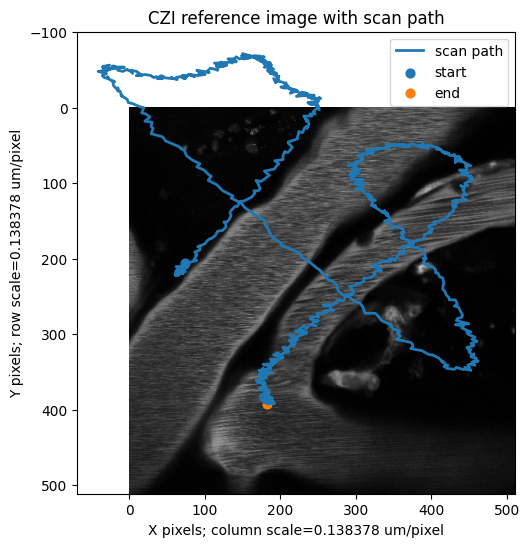

In [16]:
# For this CZI example, channel 1 contains the useful reference image data.
plane = czi_reference.get_plane(channel=1)
scan_path = czi_reference.get_scan_path_plot()

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(plane.array, cmap="gray", origin="upper")
ax.set_title("CZI reference image with scan path")
ax.set_xlabel(f"X pixels; column scale={plane.dy:g} {plane.y_unit}/pixel")
ax.set_ylabel(f"Y pixels; row scale={plane.dx:g} {plane.x_unit}/pixel")

if scan_path is not None:
    x_pixels, y_pixels = scan_path
    ax.plot(x_pixels, y_pixels, linewidth=2, label="scan path")
    ax.scatter([x_pixels[0]], [y_pixels[0]], s=40, label="start")
    ax.scatter([x_pixels[-1]], [y_pixels[-1]], s=40, label="end")
    ax.legend(loc="best")
else:
    ax.text(
        0.02,
        0.98,
        "No scan path metadata",
        transform=ax.transAxes,
        va="top",
        ha="left",
        bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.75},
    )

plt.show()

## Files without reference images

Not every acquisition file includes a reference image or scan-path metadata. Code that uses this API should handle missing metadata explicitly.

In [17]:
reference = acq.images.reference_image
if reference is None:
    print("No reference image saved in this file.")
else:
    scan_path = reference.get_scan_path_plot()
    if scan_path is None:
        print("Reference image exists, but no scan path metadata was found.")
    else:
        x_pixels, y_pixels = scan_path
        print(f"Scan path points: {len(x_pixels)}")

Scan path points: 2
